# Análisis de Clasificación de Estados - Flota 794AC Quellaveco

## Objetivo
Este notebook analiza la base de datos de muestras de aceite de la flota de camiones **794AC** de la mina **Quellaveco**. El objetivo principal es:

1. **Explorar** la base de datos y comprender las variables disponibles
2. **Construir modelos de clasificación** (XGBoost y Random Forest) para predecir el estado del aceite: `NORMAL`, `PRECAUCION` o `CRITICO`
3. **Aplicar análisis SHAP** para determinar qué variables son las más significativas en la clasificación
4. **Identificar los rangos/intervalos** de cada variable que determinan cada estado
5. **Validar con K-Means** si los clusters naturales de los datos coinciden con los estados asignados

## Estructura del Notebook
| Sección | Descripción |
|---------|-------------|
| 1 | Configuración e importación de librerías |
| 2 | Carga y exploración de datos |
| 3 | Limpieza y preparación de datos |
| 4 | Análisis exploratorio por estado (EDA) |
| 5 | Modelos de clasificación (XGBoost + Random Forest) |
| 6 | Importancia de variables (Feature Importance) |
| 7 | Análisis SHAP |
| 8 | Parámetros e intervalos determinantes por estado |
| 9 | Análisis de Clusters (K-Means) |
| 10 | Reglas de clasificación y resumen ejecutivo |

## 1. Configuración e Importación de Librerías

Importamos todas las librerías necesarias para el análisis:
- **pandas / numpy**: manipulación de datos
- **matplotlib / seaborn**: visualización
- **scikit-learn**: modelos de clasificación, preprocesamiento y métricas
- **xgboost**: modelo de gradient boosting de alto rendimiento
- **shap**: interpretabilidad del modelo (SHapley Additive exPlanations)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
import shap
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

OUTPUT_DIR = r'c:\Users\lbrya\OneDrive\Escritorio\ACEITES_MINERIA\resultados_analisis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

FILE_PATH = r'c:\Users\lbrya\OneDrive\Escritorio\ACEITES_MINERIA\DATA FLOTA 794AC - MOTOR ORIGINAL QUELLAVECO_R4L 2024.xlsx'

print("Librerías cargadas correctamente.")

c:\Users\lbrya\anaconda3\envs\PythonR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


## 2. Carga y Exploración Inicial de Datos

### 2.1 Exploración de todas las hojas del archivo Excel
El archivo contiene múltiples hojas. Primero vemos cuáles son y qué contiene cada una para entender la estructura general.

In [2]:
import openpyxl

wb = openpyxl.load_workbook(FILE_PATH, read_only=True, data_only=True)
print(f"El archivo tiene {len(wb.sheetnames)} hojas:\n")

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    rows = []
    for i, row in enumerate(ws.iter_rows(max_row=2, values_only=True)):
        rows.append(list(row))
    n_cols = len(rows[0]) if rows else 0
    print(f"  📄 {sheet_name:<25} ({n_cols} columnas)")
    if rows:
        cols_preview = [str(c) for c in rows[0][:5] if c is not None]
        if cols_preview:
            print(f"     Primeras columnas: {', '.join(cols_preview)}")
    print()

wb.close()

El archivo tiene 18 hojas:

  📄 HOLL                      (12 columnas)
     Primeras columnas: Equipo, HT001

  📄 TBN                       (5 columnas)
     Primeras columnas: Equipo, (Todas)

  📄 OXID                      (5 columnas)

  📄 100°                      (13 columnas)

  📄 FE                        (19 columnas)
     Primeras columnas: Equipo, (Todas)

  📄 FE (TD)                   (4 columnas)
     Primeras columnas: Equipo, HT001

  📄 794AC QUELLA              (58 columnas)
     Primeras columnas: Codigo, Fecha, Fecha - Año, Equipo, PRUEBA

  📄 GRAPH-SALUD (1)           (20 columnas)

  📄 GRAPH-SALUD               (20 columnas)

  📄 GRAPH-DESG (1)            (0 columnas)

  📄 GRAPH-DESG                (0 columnas)

  📄 HT001HOLLIN               (3 columnas)

  📄 HT001HIERRO               (3 columnas)

  📄 HT001POTASIO              (3 columnas)

  📄 HT017HOLLIN               (3 columnas)

  📄 HT017HIERRO               (3 columnas)

  📄 HT017POTASIO              (3 column

### 2.2 Carga de la hoja principal: `794AC QUELLA`

Esta es la base de datos principal que contiene todas las muestras de aceite con sus variables analíticas y el estado asignado a cada muestra.

In [3]:
df = pd.read_excel(FILE_PATH, sheet_name='794AC QUELLA')

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print("Primeras 5 filas:")
df.head()

Dimensiones del dataset: 3719 filas x 58 columnas

Primeras 5 filas:


,Codigo,Fecha,Fecha - Año,Equipo,PRUEBA,Hora_Producto,Producto,Estado,TBN (mg KOH/g),Viscosidad a 40 °C cSt,...,Particulas Ferrosas (PQ),Fe Acum ppm,Cr Acum ppm,Pb Acum ppm,Cu Acum ppm,Sn Acum ppm,Al Acum ppm,Si Acum ppm,Observacion,Accion_Sugerida
0,Q1696,2020-02-13,2-2020,HT005,NaN,117,RIMULA R4 X 15W40,NORMAL,9.2,96.82,...,5,3.0,0.0,0.0,2.0,0.0,0.0,15.0,1. CONTAMINACIÓN: \nNo se evidencia presencia ...,4. RECOMENDACIONES:\nContinuar con envío de mu...
1,Q640,2020-06-17,6-2020,HT001,NaN,30,RIMULA R4 X 15W40,NORMAL,10.22,NaN,...,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1. CONTAMINACIÓN:\nNo se evidencia presencia d...,NaN
2,Q803,2020-07-14,7-2020,HT001,NaN,49,RIMULA R4 X 15W40,NORMAL,10.35,-,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1. CONTAMINACIÓN: \nNo se evidencia presencia ...,NaN
3,Q796,2020-07-14,7-2020,HT003,NaN,25,RIMULA R4 L 15W40,NORMAL,9.86,NaN,...,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1. CONTAMINACIÓN: \nNo se evidencia presencia ...,NaN
4,Q775,2020-07-14,7-2020,HT002,NaN,38,RIMULA R4 X 15W40,NORMAL,9.89,-,...,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1. CONTAMINACIÓN: \nNo se evidencia presencia ...,NaN


### 2.3 Información general del dataset
Revisamos los tipos de datos, las columnas disponibles y la distribución de la variable objetivo `Estado`.

In [4]:
print("=== COLUMNAS DEL DATASET ===\n")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col} ({df[col].dtype})")

print(f"\n\n=== DISTRIBUCIÓN DE LA VARIABLE 'Estado' ===\n")
estado_counts = df['Estado'].value_counts()
estado_pct = (estado_counts / len(df) * 100).round(2)

for estado in estado_counts.index:
    print(f"  {estado:<15}: {estado_counts[estado]:>5} muestras ({estado_pct[estado]:.2f}%)")

print(f"\n  Total: {len(df)} muestras")

=== COLUMNAS DEL DATASET ===

   1. Codigo (str)
   2. Fecha (datetime64[us])
   3. Fecha - Año (str)
   4. Equipo (str)
   5. PRUEBA (str)
   6. Hora_Producto (int64)
   7. Producto (str)
   8. Estado (str)
   9. TBN (mg KOH/g) (object)
  10. Viscosidad a 40 °C cSt (object)
  11. Viscosidad a 100 °C cSt (object)
  12. Oxidación ABS/01 mm (object)
  13. Nitración ABS/01 mm (object)
  14. Sulfatación ABS/01 mm (object)
  15. Hollin ABS/01 mm (object)
  16. Glycol % (object)
  17. Diesel % (object)
  18. Agua % (object)
  19. AGUA (CRAQUEO) TRAZ/NEG   (object)
  20. Indice de Viscosidad (object)
  21. Agua ppm (object)
  22. Magnesio ppm (object)
  23. Calcio ppm (object)
  24. Zinc ppm (object)
  25. Vanadio ppm (object)
  26. Fosforo ppm (object)
  27. Molibdeno ppm (object)
  28. Manganeso ppm (object)
  29. Fierro ppm (object)
  30. TD Fe (float64)
  31. Cromo ppm (object)
  32. Plomo ppm (object)
  33. TD Pb (float64)
  34. Cobre ppm (object)
  35. TD Cu (float64)
  36. Estaño ppm (

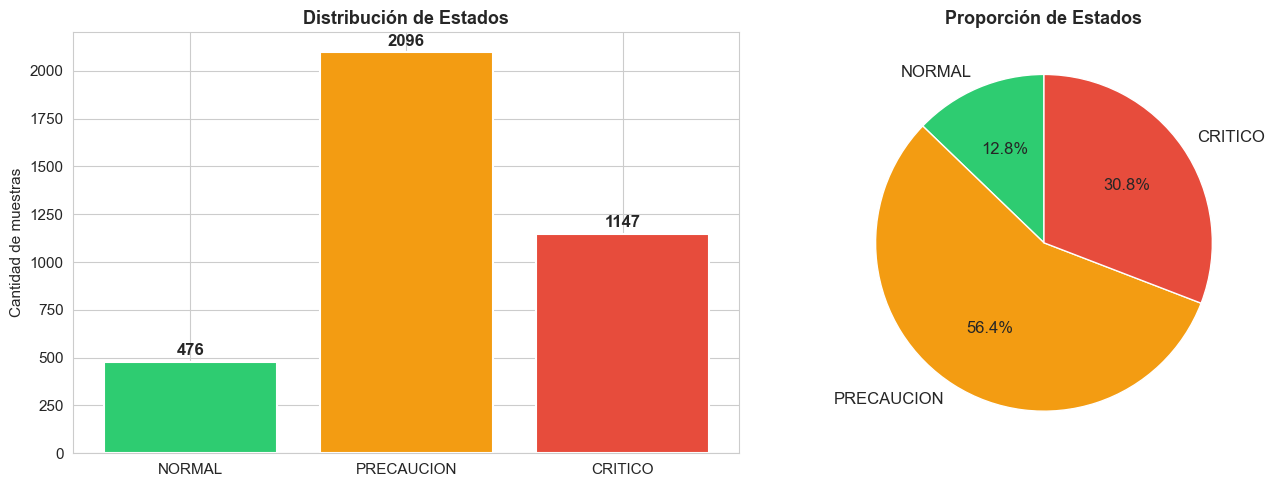

In [5]:
# Gráfico de distribución de la variable Estado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'NORMAL': '#2ecc71', 'PRECAUCION': '#f39c12', 'CRITICO': '#e74c3c'}
order = ['NORMAL', 'PRECAUCION', 'CRITICO']

estado_ordered = df['Estado'].value_counts().reindex(order)
bars = axes[0].bar(order, estado_ordered.values, color=[colors[e] for e in order], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, estado_ordered.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val),
                ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución de Estados', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Cantidad de muestras')

axes[1].pie(estado_ordered.values, labels=order, autopct='%1.1f%%',
           colors=[colors[e] for e in order], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción de Estados', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

## 3. Limpieza y Preparación de Datos

### 3.1 Selección de variables features
Excluimos las columnas que son identificadores, texto libre o la variable objetivo (`Estado`). Solo conservamos las variables numéricas que representan las propiedades analíticas del aceite.

In [6]:
# Columnas a excluir: identificadores, texto, variable objetivo
cols_excluir = ['Codigo', 'Fecha', 'Fecha - Año', 'Equipo', 'PRUEBA', 'Producto',
                'Estado', 'Observacion', 'Accion_Sugerida', 'AGUA (CRAQUEO) TRAZ/NEG ']

feature_cols = [c for c in df.columns if c not in cols_excluir]

print(f"Variables feature candidatas: {len(feature_cols)}\n")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {c}")

Variables feature candidatas: 49

   1. Hora_Producto
   2. TBN (mg KOH/g)
   3. Viscosidad a 40 °C cSt
   4. Viscosidad a 100 °C cSt
   5. Oxidación ABS/01 mm
   6. Nitración ABS/01 mm
   7. Sulfatación ABS/01 mm
   8. Hollin ABS/01 mm
   9. Glycol %
  10. Diesel %
  11. Agua %
  12. AGUA (CRAQUEO) TRAZ/NEG  
  13. Indice de Viscosidad
  14. Agua ppm
  15. Magnesio ppm
  16. Calcio ppm
  17. Zinc ppm
  18. Vanadio ppm
  19. Fosforo ppm
  20. Molibdeno ppm
  21. Manganeso ppm
  22. Fierro ppm
  23. TD Fe
  24. Cromo ppm
  25. Plomo ppm
  26. TD Pb
  27. Cobre ppm
  28. TD Cu
  29. Estaño ppm
  30. Aluminio ppm
  31. Niquel ppm
  32. Plata ppm
  33. Litio ppm
  34. Antimonio ppm
  35. Titanio ppm
  36. Cadmio ppm
  37. Silicio ppm
  38. Potasio ppm
  39. Boro ppm
  40. Sodio ppm
  41. Bario  ppm
  42. Particulas Ferrosas (PQ) 
  43. Fe Acum ppm
  44. Cr Acum ppm
  45. Pb Acum ppm
  46. Cu Acum ppm
  47. Sn Acum ppm
  48. Al Acum ppm
  49. Si Acum ppm


### 3.2 Conversión de tipos y manejo de valores nulos

Algunas columnas numéricas fueron leídas como texto (`object`). Las convertimos a tipo numérico. Luego:
- **Eliminamos** columnas con más de 50% de valores nulos (no son confiables para el modelo)
- **Imputamos** los valores nulos restantes con la **mediana** de cada columna (robusta frente a outliers)

In [7]:
df_model = df[feature_cols + ['Estado']].copy()

# Convertir columnas object a numérico
for col in feature_cols:
    if df_model[col].dtype == 'object':
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Eliminar columnas con >50% nulos
pct_null = df_model[feature_cols].isnull().sum() / len(df_model) * 100
cols_drop = pct_null[pct_null > 50].index.tolist()
print(f"Columnas eliminadas por >50% nulos:")
for c in cols_drop:
    print(f"  ❌ {c} ({pct_null[c]:.1f}% nulos)")

feature_cols = [c for c in feature_cols if c not in cols_drop]
df_model = df_model[feature_cols + ['Estado']]

Columnas eliminadas por >50% nulos:
  ❌ Viscosidad a 40 °C cSt (69.0% nulos)
  ❌ AGUA (CRAQUEO) TRAZ/NEG   (100.0% nulos)
  ❌ Indice de Viscosidad (73.5% nulos)
  ❌ Agua ppm (99.7% nulos)


In [8]:
# Revisar nulos restantes
print("Nulos restantes antes de imputación:\n")
nulls = df_model[feature_cols].isnull().sum()
nulls_nonzero = nulls[nulls > 0].sort_values(ascending=False)

null_summary = pd.DataFrame({
    'Nulos': nulls_nonzero,
    '% del total': (nulls_nonzero / len(df_model) * 100).round(1)
})
print(null_summary.to_string())

# Imputar con la mediana
for col in feature_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna(df_model[col].median())

df_model = df_model.dropna(subset=['Estado'])

print(f"\n\nDataset final para modelado: {df_model.shape[0]} filas x {len(feature_cols)} features")
print(f"Nulos restantes: {df_model[feature_cols].isnull().sum().sum()}")

Nulos restantes antes de imputación:

                           Nulos  % del total
Si Acum ppm                 1358         36.5
Al Acum ppm                 1358         36.5
Sn Acum ppm                 1354         36.4
Cu Acum ppm                 1354         36.4
Cr Acum ppm                 1354         36.4
Pb Acum ppm                 1354         36.4
Fe Acum ppm                 1354         36.4
Diesel %                     952         25.6
Glycol %                     160          4.3
Agua %                       159          4.3
Litio ppm                    113          3.0
Antimonio ppm                113          3.0
Potasio ppm                   45          1.2
Particulas Ferrosas (PQ)      16          0.4
Sodio ppm                      7          0.2
Bario  ppm                     7          0.2
Viscosidad a 100 °C cSt        6          0.2
TBN (mg KOH/g)                 3          0.1
Oxidación ABS/01 mm            3          0.1
Nitración ABS/01 mm            3          

## 4. Análisis Exploratorio por Estado (EDA)

### 4.1 Estadísticas descriptivas por estado
Calculamos la media de cada variable agrupada por estado para ver cómo difieren los valores entre `NORMAL`, `PRECAUCION` y `CRITICO`.

In [9]:
# Estadísticas completas por estado (se guardan en Excel)
stats_by_estado = df_model.groupby('Estado')[feature_cols].agg(['mean', 'median', 'std', 'min', 'max'])
stats_by_estado.to_excel(os.path.join(OUTPUT_DIR, 'estadisticas_por_estado.xlsx'))

# Mostrar las medias por estado
means = df_model.groupby('Estado')[feature_cols].mean().T
means = means[['NORMAL', 'PRECAUCION', 'CRITICO']]

print("MEDIAS POR ESTADO\n")
print(means.round(3).to_string())

MEDIAS POR ESTADO

Estado                       NORMAL  PRECAUCION   CRITICO
Hora_Producto               131.107     299.138   448.880
TBN (mg KOH/g)                8.708       8.408     7.887
Viscosidad a 100 °C cSt      14.149      13.414    13.361
Oxidación ABS/01 mm           0.024       0.039     0.053
Nitración ABS/01 mm           0.021       0.042     0.060
Sulfatación ABS/01 mm         0.016       0.034     0.051
Hollin ABS/01 mm              0.302       0.543     0.846
Glycol %                      0.000       0.008     0.000
Diesel %                      0.033       1.672     0.202
Agua %                        0.000       0.518     0.000
Magnesio ppm                233.399     245.136   234.249
Calcio ppm                 2208.046    2307.994  2450.207
Zinc ppm                   1355.920    1356.686  1332.460
Vanadio ppm                   4.046       4.719     4.493
Fosforo ppm                1164.933    1181.855  1201.380
Molibdeno ppm                52.046      56.184    57

### 4.2 Boxplots por estado
Los boxplots permiten visualizar cómo se distribuye cada variable dentro de cada estado. Las diferencias visibles entre cajas confirman qué variables tienen poder discriminante.

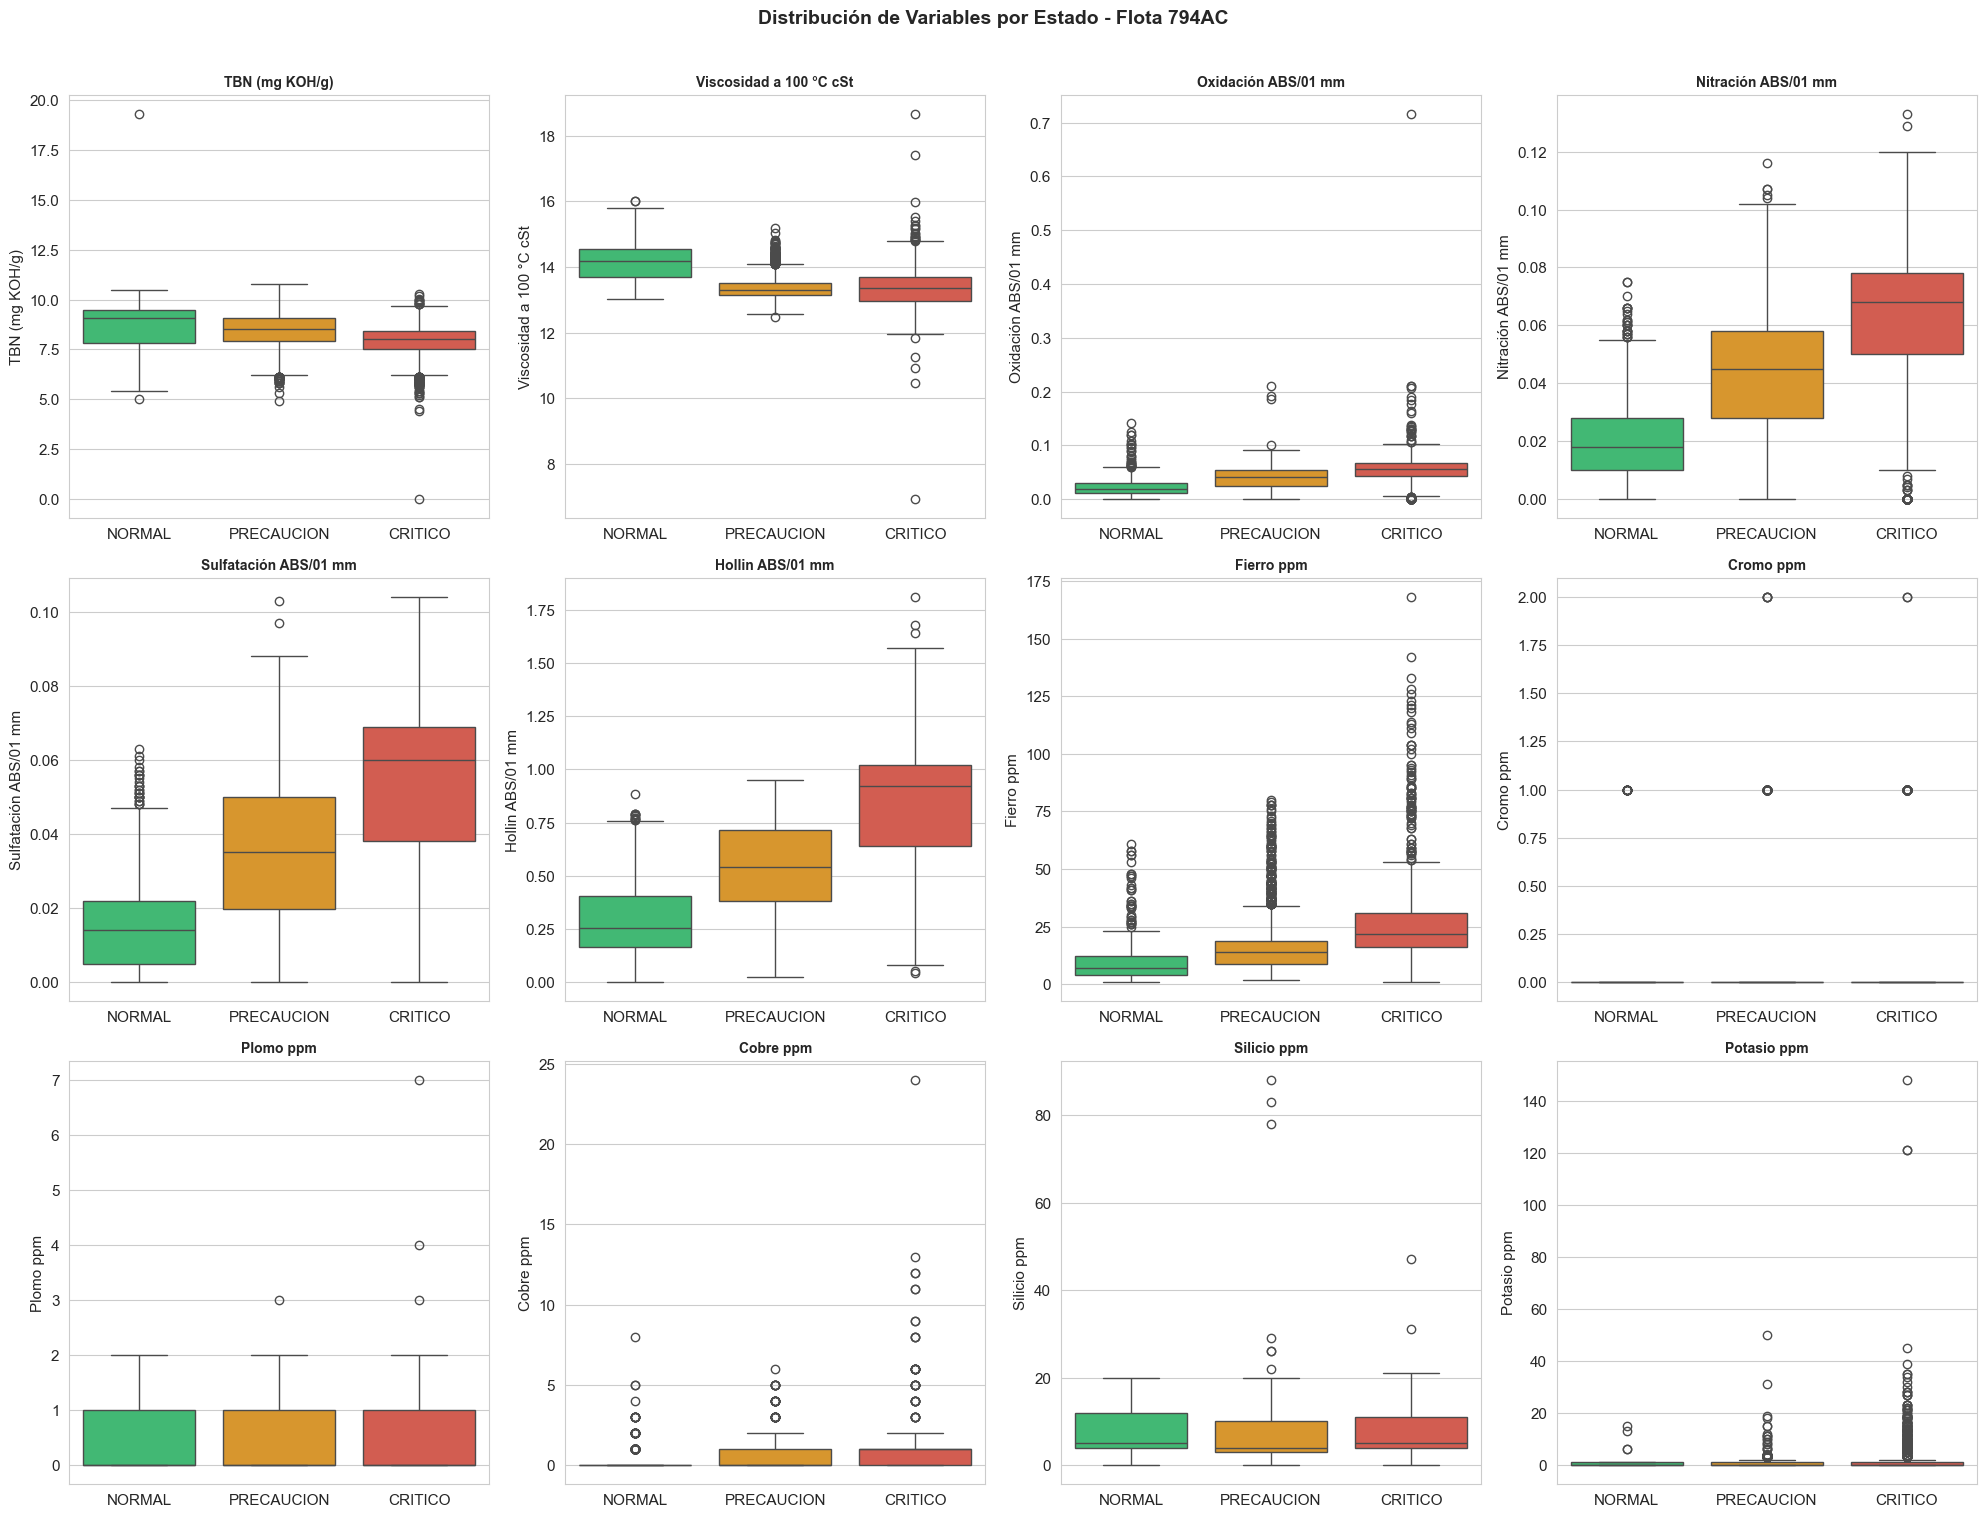

In [10]:
# Seleccionar las 12 variables más relevantes para los boxplots
top_vars = ['TBN (mg KOH/g)', 'Viscosidad a 100 °C cSt', 'Oxidación ABS/01 mm',
            'Nitración ABS/01 mm', 'Sulfatación ABS/01 mm', 'Hollin ABS/01 mm',
            'Fierro ppm', 'Cromo ppm', 'Plomo ppm', 'Cobre ppm', 'Silicio ppm', 'Potasio ppm']
top_vars_exist = [v for v in top_vars if v in feature_cols]
if not top_vars_exist:
    top_vars_exist = feature_cols[:12]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
order = ['NORMAL', 'PRECAUCION', 'CRITICO']
palette = {'NORMAL': '#2ecc71', 'PRECAUCION': '#f39c12', 'CRITICO': '#e74c3c'}

for i, var in enumerate(top_vars_exist[:12]):
    ax = axes[i]
    data_plot = df_model[df_model['Estado'].isin(order)]
    sns.boxplot(data=data_plot, x='Estado', y=var, order=order, ax=ax, palette=palette)
    ax.set_title(var, fontsize=10, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(top_vars_exist), 12):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables por Estado - Flota 794AC', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'boxplots_por_estado.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Modelos de Clasificación

Entrenamos dos modelos supervisados para predecir el `Estado` a partir de las variables analíticas:

### ¿Por qué XGBoost y Random Forest?
- **XGBoost**: algoritmo de gradient boosting que construye árboles secuencialmente, corrigiendo errores previos. Excelente para datos tabulares.
- **Random Forest**: ensamble de árboles independientes que votan la clase. Robusto y menos propenso a sobreajuste.

Ambos son modelos basados en árboles, lo que los hace ideales para análisis SHAP posterior.

### 5.1 Preparación: codificación y split train/test

In [11]:
# Preparar X (features) e y (variable objetivo codificada)
X = df_model[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(df_model['Estado'])
class_names = le.classes_

print("Codificación de clases:")
for code, name in enumerate(class_names):
    print(f"  {code} → {name}")

# Dividir en train (75%) y test (25%), estratificado para mantener proporciones
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nConjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba:        {X_test.shape[0]} muestras")

Codificación de clases:
  0 → CRITICO
  1 → NORMAL
  2 → PRECAUCION

Conjunto de entrenamiento: 2789 muestras
Conjunto de prueba:        930 muestras


### 5.2 Entrenamiento del modelo XGBoost

Hiperparámetros seleccionados:
- `n_estimators=300`: cantidad de árboles en el ensamble
- `max_depth=6`: profundidad máxima de cada árbol (controla complejidad)
- `learning_rate=0.1`: tasa de aprendizaje
- `subsample=0.8`: proporción de datos usados por cada árbol
- `colsample_bytree=0.8`: proporción de features usadas por cada árbol

In [12]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"Accuracy XGBoost: {acc_xgb:.4f}\n")
print("Reporte de Clasificación (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

Accuracy XGBoost: 0.9548

Reporte de Clasificación (XGBoost):
              precision    recall  f1-score   support

     CRITICO       0.96      0.95      0.96       287
      NORMAL       0.92      0.92      0.92       119
  PRECAUCION       0.96      0.97      0.96       524

    accuracy                           0.95       930
   macro avg       0.95      0.94      0.95       930
weighted avg       0.95      0.95      0.95       930



### 5.3 Validación cruzada (Cross-Validation)
Evaluamos la robustez del modelo con validación cruzada estratificada de 5 pliegues. Esto asegura que el rendimiento no depende de una partición particular de los datos.

In [13]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy')

print("Resultados de Cross-Validation (5-fold):\n")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Media:  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"\n  → El modelo es estable: la variación entre folds es mínima ({cv_scores.std():.4f})")

Resultados de Cross-Validation (5-fold):

  Fold 1: 0.9556
  Fold 2: 0.9583
  Fold 3: 0.9489
  Fold 4: 0.9556
  Fold 5: 0.9542

  Media:  0.9546 (+/- 0.0031)

  → El modelo es estable: la variación entre folds es mínima (0.0031)


### 5.4 Entrenamiento del modelo Random Forest
Segundo modelo como punto de comparación. Random Forest es más simple pero igualmente potente para datos tabulares.

In [14]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy Random Forest: {acc_rf:.4f}\n")
print("Reporte de Clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

Accuracy Random Forest: 0.9387

Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

     CRITICO       0.97      0.94      0.95       287
      NORMAL       0.93      0.79      0.85       119
  PRECAUCION       0.93      0.97      0.95       524

    accuracy                           0.94       930
   macro avg       0.94      0.90      0.92       930
weighted avg       0.94      0.94      0.94       930



### 5.5 Matrices de Confusión
La matriz de confusión muestra cuántas muestras fueron clasificadas correctamente (diagonal) y cuántas fueron confundidas entre estados.

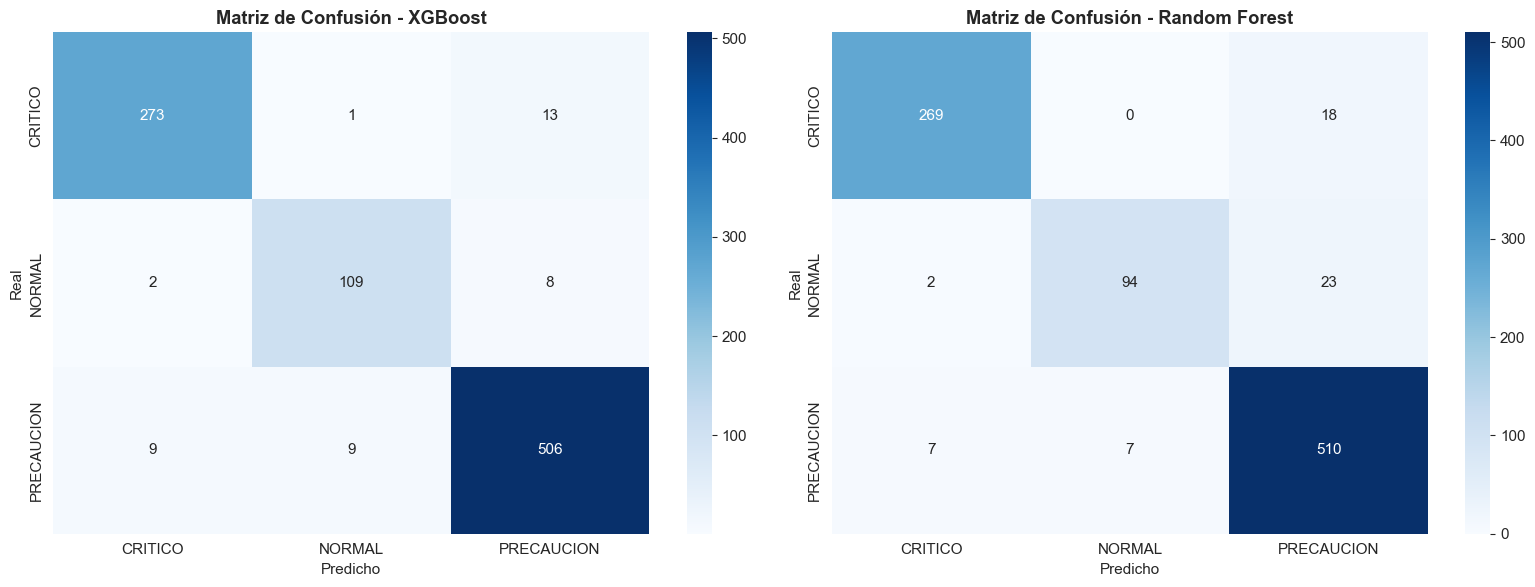


Comparación de modelos:
  XGBoost:       0.9548 accuracy
  Random Forest: 0.9387 accuracy
  Mejor modelo: XGBoost


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(axes, [y_pred_xgb, y_pred_rf], ['XGBoost', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Matriz de Confusión - {title}', fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'matrices_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nComparación de modelos:")
print(f"  XGBoost:       {acc_xgb:.4f} accuracy")
print(f"  Random Forest: {acc_rf:.4f} accuracy")
print(f"  Mejor modelo: {'XGBoost' if acc_xgb >= acc_rf else 'Random Forest'}")

## 6. Importancia de Variables (Feature Importance)

La importancia de variables nativa de los modelos basados en árboles indica cuánto contribuye cada variable a las decisiones de clasificación. Comparamos ambos modelos para ver si coinciden en las variables más relevantes.

In [16]:
importances = pd.DataFrame({
    'Variable': feature_cols,
    'Importancia_RF': rf_model.feature_importances_,
    'Importancia_XGB': xgb_model.feature_importances_
}).sort_values('Importancia_RF', ascending=False)

print("Top 20 Variables más importantes:\n")
print(importances.head(20).to_string(index=False))

Top 20 Variables más importantes:

               Variable  Importancia_RF  Importancia_XGB
       Hollin ABS/01 mm        0.175106         0.132295
Viscosidad a 100 °C cSt        0.153410         0.072498
          Hora_Producto        0.088673         0.075541
    Nitración ABS/01 mm        0.056703         0.018593
            Potasio ppm        0.049238         0.082328
  Sulfatación ABS/01 mm        0.045670         0.022764
             Fierro ppm        0.039536         0.024484
               Boro ppm        0.034323         0.014467
                  TD Fe        0.032998         0.011174
         TBN (mg KOH/g)        0.030809         0.023133
    Oxidación ABS/01 mm        0.027840         0.009178
              Sodio ppm        0.025099         0.034446
             Calcio ppm        0.019138         0.008461
            Fosforo ppm        0.017363         0.010387
               Zinc ppm        0.016270         0.008377
                  TD Cu        0.016185         0.006

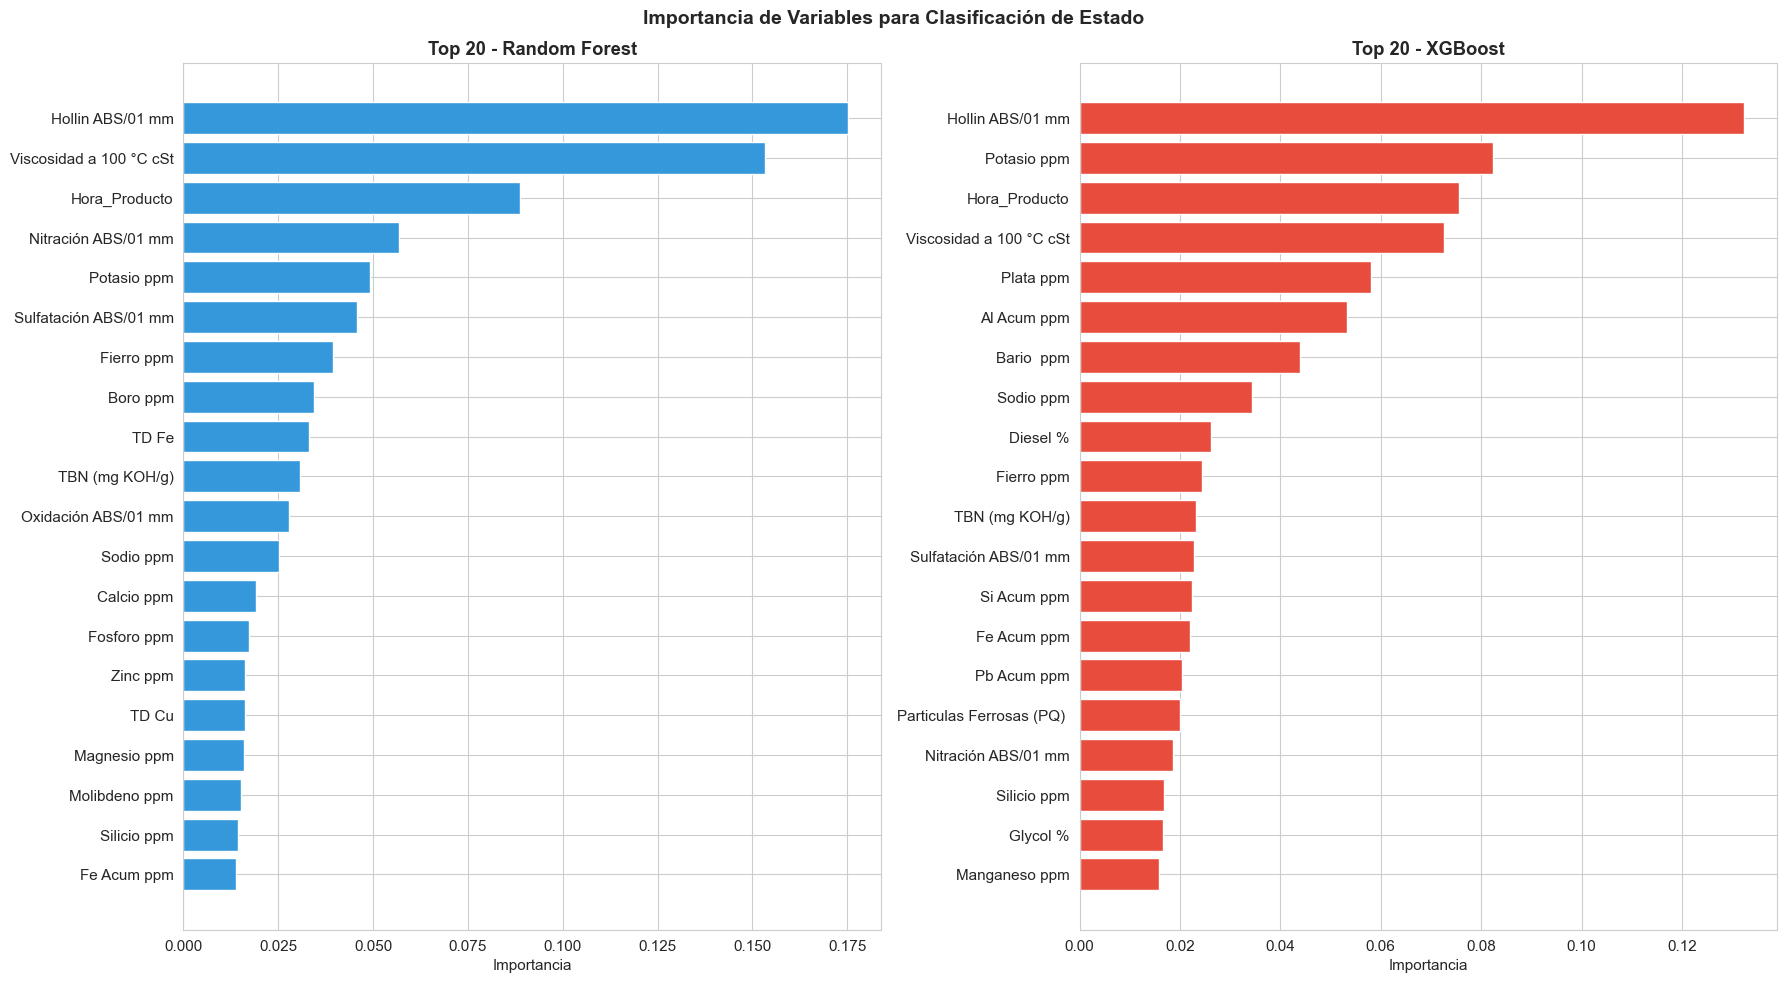

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Random Forest
top20_rf = importances.head(20)
axes[0].barh(range(20), top20_rf['Importancia_RF'].values, color='#3498db')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20_rf['Variable'].values)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 - Random Forest', fontweight='bold')
axes[0].set_xlabel('Importancia')

# XGBoost
top20_xgb = importances.sort_values('Importancia_XGB', ascending=False).head(20)
axes[1].barh(range(20), top20_xgb['Importancia_XGB'].values, color='#e74c3c')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top20_xgb['Variable'].values)
axes[1].invert_yaxis()
axes[1].set_title('Top 20 - XGBoost', fontweight='bold')
axes[1].set_xlabel('Importancia')

plt.suptitle('Importancia de Variables para Clasificación de Estado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis SHAP (SHapley Additive exPlanations)

### ¿Qué es SHAP?
SHAP es un método de interpretabilidad basado en la **teoría de juegos** (valores de Shapley). Para cada predicción, SHAP calcula la contribución de **cada variable** al resultado final.

**Ventajas sobre Feature Importance tradicional:**
- Es **consistente**: si una variable tiene mayor impacto real, SHAP le asigna mayor valor
- Muestra la **dirección** del efecto (positivo o negativo)
- Permite análisis **por clase** (NORMAL, PRECAUCION, CRITICO)

### 7.1 Cálculo de SHAP Values
Usamos `TreeExplainer` que es el método exacto y rápido para modelos basados en árboles.

In [18]:
# Calcular SHAP values usando TreeExplainer (exacto para modelos de árboles)
explainer = shap.TreeExplainer(xgb_model)
shap_values_raw = explainer.shap_values(X_test)

# Adaptar formato según la versión de SHAP
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
    n_classes = len(shap_values)
else:
    if shap_values_raw.ndim == 3:
        shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
        n_classes = len(shap_values)
    else:
        shap_values = [shap_values_raw]
        n_classes = 1

X_test_df = pd.DataFrame(X_test, columns=feature_cols)

print(f"SHAP values calculados para {n_classes} clases")
print(f"Shape por clase: {shap_values[0].shape}")
print(f"Clases: {list(class_names[:n_classes])}")

SHAP values calculados para 3 clases
Shape por clase: (930, 45)
Clases: ['CRITICO', 'NORMAL', 'PRECAUCION']


### 7.2 SHAP Summary Plot Global
Este gráfico muestra la importancia SHAP global promediada entre todas las clases. Cuanto mayor el valor SHAP medio absoluto, más impacto tiene la variable en la clasificación.

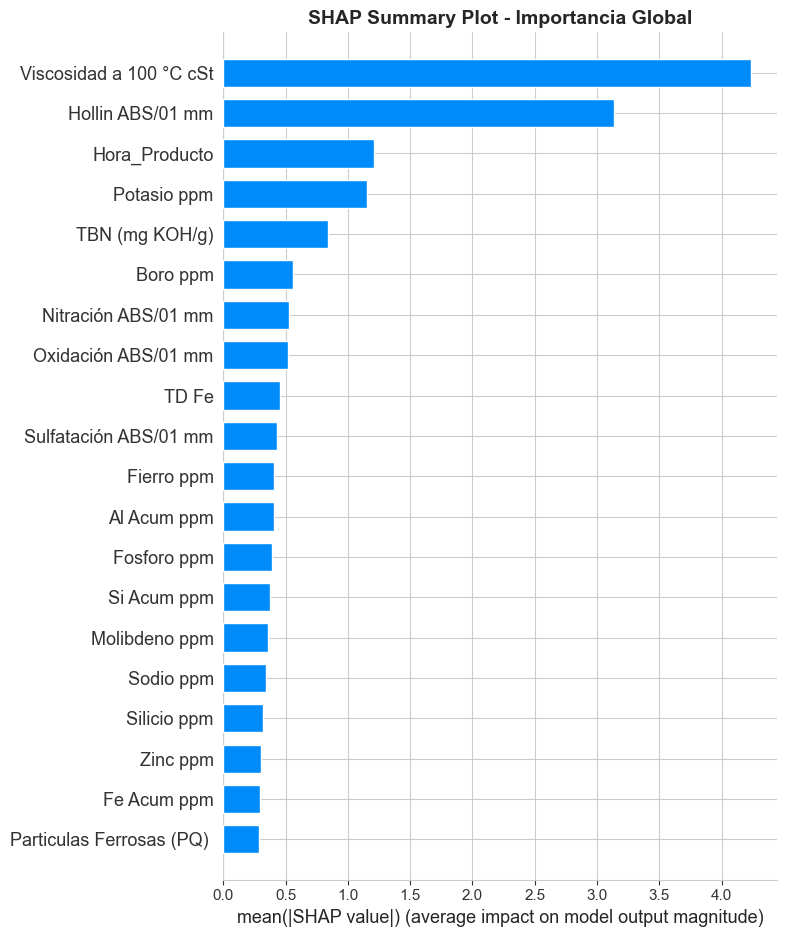

In [19]:
# SHAP Summary Plot global (bar plot de importancia)
fig, ax = plt.subplots(figsize=(14, 10))

if n_classes > 1:
    shap_abs_all = np.zeros_like(shap_values[0])
    for sv in shap_values:
        shap_abs_all += np.abs(sv)
    shap.summary_plot(shap_abs_all, X_test_df, feature_names=feature_cols,
                      show=False, max_display=20, plot_type='bar')
else:
    shap.summary_plot(shap_values[0], X_test_df, feature_names=feature_cols,
                      show=False, max_display=20)

plt.title('SHAP Summary Plot - Importancia Global', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_summary_global.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.3 SHAP Summary Plot por Clase

Estos gráficos muestran cómo cada variable influye en la predicción de **cada clase específica**.

**Cómo leerlos:**
- Cada punto es una muestra del conjunto de prueba
- **Eje X**: valor SHAP (impacto en la predicción)
  - Positivo → empuja hacia clasificar como esa clase
  - Negativo → empuja contra esa clase
- **Color**: valor de la variable
  - 🔴 Rojo = valor alto de la variable
  - 🔵 Azul = valor bajo de la variable

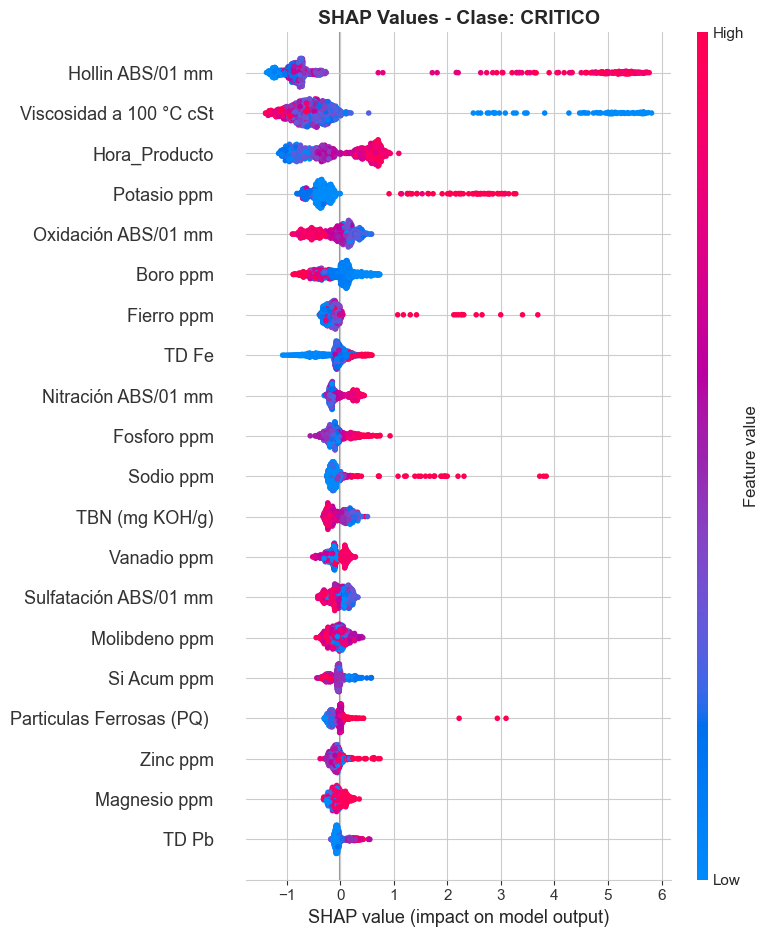

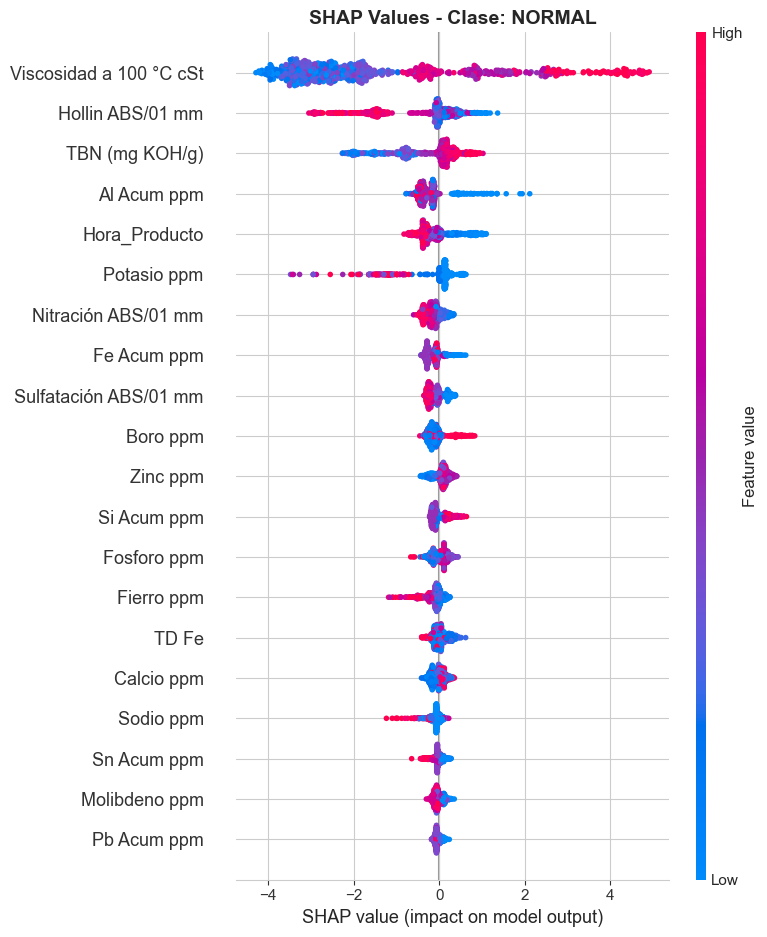

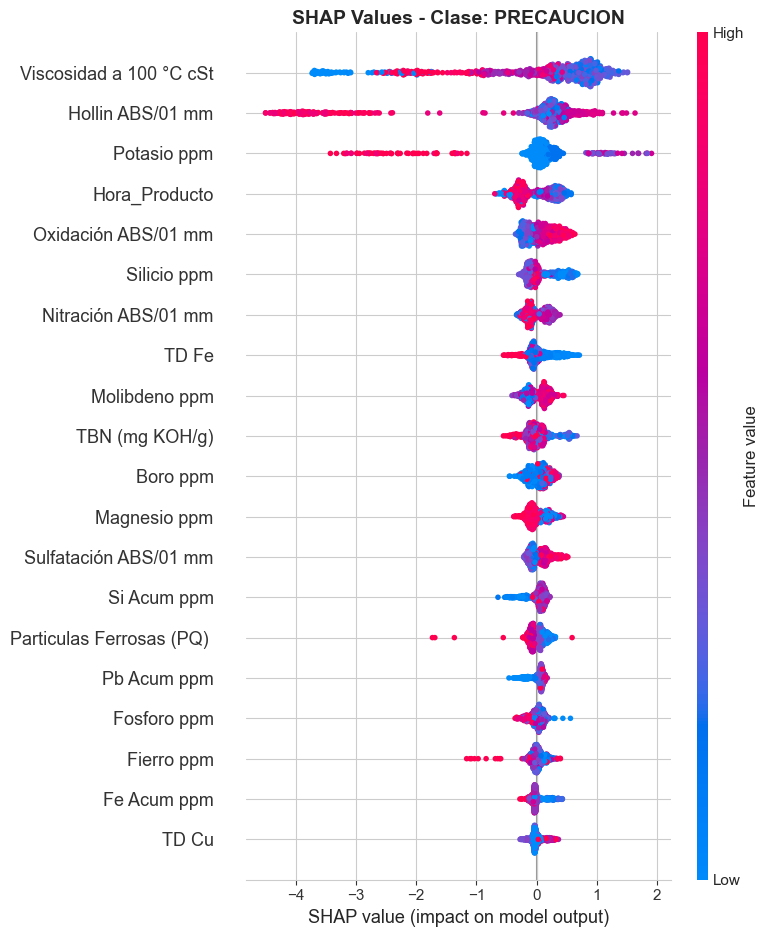

In [20]:
# SHAP summary plot para cada clase
for i, clase in enumerate(class_names[:n_classes]):
    fig, ax = plt.subplots(figsize=(14, 10))
    shap.summary_plot(shap_values[i], X_test_df, feature_names=feature_cols,
                      show=False, max_display=20)
    plt.title(f'SHAP Values - Clase: {clase}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'shap_summary_{clase}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print()

### 7.4 Importancia SHAP media absoluta por clase
Tabla numérica que muestra las Top 15 variables más influyentes para predecir cada estado.

In [21]:
for i, clase in enumerate(class_names[:n_classes]):
    shap_abs_mean = np.abs(shap_values[i]).mean(axis=0)
    shap_df = pd.DataFrame({
        'Variable': feature_cols,
        'SHAP_mean_abs': shap_abs_mean
    }).sort_values('SHAP_mean_abs', ascending=False)

    print(f"{'='*55}")
    print(f"  Top 15 variables para la clase '{clase}'")
    print(f"{'='*55}")
    print(f"  {'Variable':<35} {'SHAP medio |abs|':>15}")
    print(f"  {'-'*50}")
    for _, row in shap_df.head(15).iterrows():
        print(f"  {row['Variable']:<35} {row['SHAP_mean_abs']:>15.4f}")
    print()

  Top 15 variables para la clase 'CRITICO'
  Variable                            SHAP medio |abs|
  --------------------------------------------------
  Hollin ABS/01 mm                             1.5489
  Viscosidad a 100 °C cSt                      0.8867
  Hora_Producto                                0.5991
  Potasio ppm                                  0.5016
  Oxidación ABS/01 mm                          0.2709
  Boro ppm                                     0.2667
  Fierro ppm                                   0.1937
  TD Fe                                        0.1875
  Nitración ABS/01 mm                          0.1831
  Fosforo ppm                                  0.1730
  Sodio ppm                                    0.1686
  TBN (mg KOH/g)                               0.1660
  Vanadio ppm                                  0.1449
  Sulfatación ABS/01 mm                        0.1442
  Molibdeno ppm                                0.1333

  Top 15 variables para la clase 'NORM

### 7.5 SHAP Bar Plot Global
Ranking unificado de importancia SHAP promediando el valor absoluto medio entre las 3 clases.

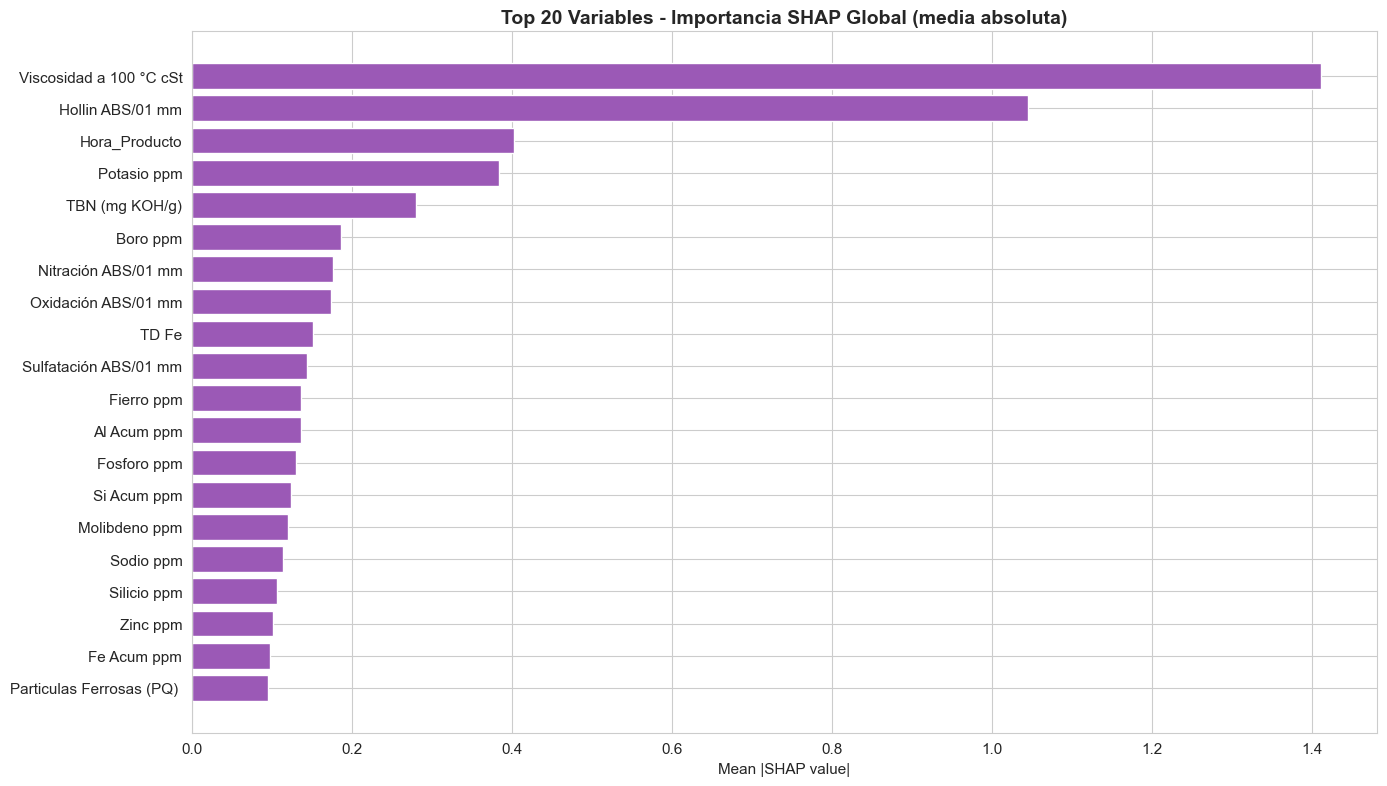

In [22]:
# Importancia SHAP global (promedio entre clases)
shap_global_importance = np.zeros(len(feature_cols))
for i in range(n_classes):
    shap_global_importance += np.abs(shap_values[i]).mean(axis=0)
shap_global_importance /= n_classes

shap_imp_df = pd.DataFrame({
    'Variable': feature_cols,
    'SHAP_Importancia': shap_global_importance
}).sort_values('SHAP_Importancia', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 8))
plt.barh(range(20), shap_imp_df['SHAP_Importancia'].values[::-1], color='#9b59b6')
plt.yticks(range(20), shap_imp_df['Variable'].values[::-1])
plt.title('Top 20 Variables - Importancia SHAP Global (media absoluta)', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_bar_global.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Parámetros e Intervalos Determinantes por Estado

Esta es la tabla clave del análisis: muestra los **rangos estadísticos** (mín, P25, mediana, P75, máx) de cada variable importante, separados por estado. Estos intervalos definen los **umbrales** que caracterizan cada condición del aceite.

In [23]:
top_features = shap_imp_df['Variable'].tolist()

intervals_data = []
for var in top_features:
    for estado in ['NORMAL', 'PRECAUCION', 'CRITICO']:
        subset = df_model[df_model['Estado'] == estado][var]
        intervals_data.append({
            'Variable': var,
            'Estado': estado,
            'Min': subset.min(),
            'P25': subset.quantile(0.25),
            'Mediana': subset.median(),
            'P75': subset.quantile(0.75),
            'Max': subset.max(),
            'Media': subset.mean()
        })

intervals_df = pd.DataFrame(intervals_data)
intervals_df.to_excel(os.path.join(OUTPUT_DIR, 'intervalos_por_estado.xlsx'), index=False)

# Mostrar la tabla formateada
print(f"{'Variable':<35} {'Estado':<15} {'Min':>10} {'P25':>10} {'Mediana':>10} {'P75':>10} {'Max':>10} {'Media':>10}")
print("=" * 115)

for var in top_features:
    for estado in ['NORMAL', 'PRECAUCION', 'CRITICO']:
        row = intervals_df[(intervals_df['Variable'] == var) & (intervals_df['Estado'] == estado)].iloc[0]
        print(f"{var:<35} {estado:<15} {row['Min']:>10.3f} {row['P25']:>10.3f} {row['Mediana']:>10.3f} {row['P75']:>10.3f} {row['Max']:>10.3f} {row['Media']:>10.3f}")
    print()

Variable                            Estado                 Min        P25    Mediana        P75        Max      Media
Viscosidad a 100 °C cSt             NORMAL              13.030     13.690     14.170     14.550     16.020     14.149
Viscosidad a 100 °C cSt             PRECAUCION          12.490     13.140     13.300     13.520     15.200     13.414
Viscosidad a 100 °C cSt             CRITICO              6.930     12.970     13.360     13.700     18.660     13.361

Hollin ABS/01 mm                    NORMAL               0.000      0.165      0.254      0.403      0.883      0.302
Hollin ABS/01 mm                    PRECAUCION           0.023      0.382      0.540      0.716      0.949      0.543
Hollin ABS/01 mm                    CRITICO              0.044      0.638      0.920      1.020      1.811      0.846

Hora_Producto                       NORMAL               1.000     48.000     85.000    184.250    631.000    131.107
Hora_Producto                       PRECAUCION        

## 9. Análisis de Clusters (K-Means) - Validación

### ¿Por qué K-Means como validación?
Aplicamos clustering K-Means con 3 clusters para verificar si los datos se agrupan naturalmente en 3 grupos similares a los estados. Si los clusters coinciden con los estados, significa que la clasificación es coherente con la estructura natural de los datos.

**Nota:** K-Means es un método **no supervisado** (no usa las etiquetas de Estado). Encontrar coincidencia con los estados sería una validación adicional de que los patrones son reales.

In [24]:
# Estandarizar los datos (K-Means requiere escala uniforme)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[feature_cols])

# Aplicar K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_model_cluster = df_model.copy()
df_model_cluster['Cluster'] = clusters

# Tabla cruzada: Estado real vs Cluster asignado
print("Tabla cruzada: Estado vs Cluster K-Means\n")
cross_tab = pd.crosstab(df_model_cluster['Estado'], df_model_cluster['Cluster'],
                        margins=True, margins_name='Total')
print(cross_tab)

print("\n\nPorcentaje de cada Estado dentro de cada Cluster:\n")
cross_pct = pd.crosstab(df_model_cluster['Estado'], df_model_cluster['Cluster'],
                        normalize='columns') * 100
print(cross_pct.round(2))

Tabla cruzada: Estado vs Cluster K-Means

Cluster        0     1  2  Total
Estado                          
CRITICO      800   347  0   1147
NORMAL       334   142  0    476
PRECAUCION  1547   548  1   2096
Total       2681  1037  1   3719


Porcentaje de cada Estado dentro de cada Cluster:

Cluster         0      1      2
Estado                         
CRITICO     29.84  33.46    0.0
NORMAL      12.46  13.69    0.0
PRECAUCION  57.70  52.84  100.0


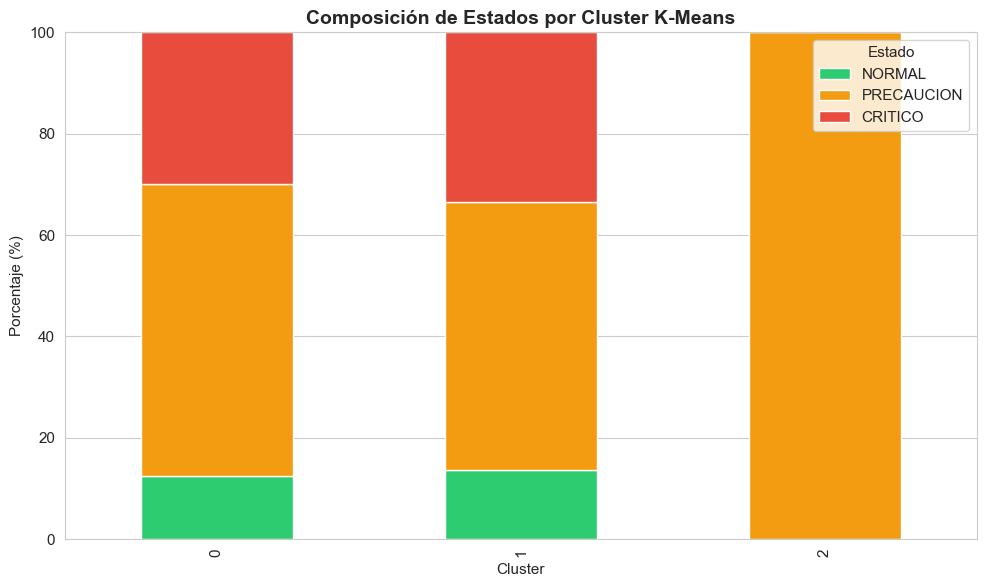

In [25]:
# Gráfico: composición de estados por cluster
fig, ax = plt.subplots(figsize=(10, 6))
cross_pct_plot = pd.crosstab(df_model_cluster['Cluster'], df_model_cluster['Estado'],
                             normalize='index') * 100
cross_pct_plot[['NORMAL', 'PRECAUCION', 'CRITICO']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2ecc71', '#f39c12', '#e74c3c']
)
plt.title('Composición de Estados por Cluster K-Means', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Estado')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clusters_vs_estado.png'), dpi=150, bbox_inches='tight')
plt.show()

### 9.1 Centroides de los clusters
Los centroides representan el "centro" de cada cluster en las variables originales. Comparándolos podemos ver qué valores típicos tiene cada grupo.

In [26]:
# Centroides en escala original
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroids_df.index = [f'Cluster_{i}' for i in range(3)]

# Mostrar solo las top 15 variables del SHAP
top15_vars = shap_imp_df['Variable'].head(15).tolist()
top15_exist = [v for v in top15_vars if v in feature_cols]

print("Centroides de los clusters (Top 15 variables SHAP):\n")
print(centroids_df[top15_exist].T.round(3).to_string())

Centroides de los clusters (Top 15 variables SHAP):

                         Cluster_0  Cluster_1  Cluster_2
Viscosidad a 100 °C cSt     13.596     13.223     13.160
Hollin ABS/01 mm             0.619      0.569      0.513
Hora_Producto              321.315    330.055    554.000
Potasio ppm                  1.349      0.941      1.000
TBN (mg KOH/g)               8.032      8.942      8.120
Boro ppm                    86.090    314.836    349.000
Nitración ABS/01 mm          0.050      0.033      0.005
Oxidación ABS/01 mm          0.048      0.026      0.013
TD Fe                        0.088      0.120      0.125
Sulfatación ABS/01 mm        0.043      0.022      0.000
Fierro ppm                  15.043     29.236     69.000
Al Acum ppm                 21.470     14.220      9.000
Fosforo ppm               1229.481   1072.687   1045.000
Si Acum ppm                146.508    104.537     55.000
Molibdeno ppm               63.519     37.281     36.000


## 10. Reglas de Clasificación y Resumen Ejecutivo

### 10.1 Rangos típicos (P10-P90) de las Top 10 variables
El rango P10-P90 cubre el 80% central de los datos de cada estado, eliminando valores extremos. Estos rangos son los más útiles para definir **umbrales operativos** de clasificación.

In [27]:
top10 = shap_imp_df['Variable'].head(10).tolist()

print("Las 10 variables más determinantes para la clasificación del Estado")
print("=" * 75)

for i, var in enumerate(top10, 1):
    print(f"\n  {i}. {var}")
    print(f"     {'Estado':<15}  {'Rango típico (P10-P90)':<30}  {'Mediana':>10}")
    print(f"     {'-'*60}")
    for estado in ['NORMAL', 'PRECAUCION', 'CRITICO']:
        subset = df_model[df_model['Estado'] == estado][var]
        p10 = subset.quantile(0.10)
        p90 = subset.quantile(0.90)
        med = subset.median()
        print(f"     {estado:<15}  [{p10:>10.3f}  -  {p90:<10.3f}]  {med:>10.3f}")

Las 10 variables más determinantes para la clasificación del Estado

  1. Viscosidad a 100 °C cSt
     Estado           Rango típico (P10-P90)             Mediana
     ------------------------------------------------------------
     NORMAL           [    13.565  -  14.800    ]      14.170
     PRECAUCION       [    13.015  -  14.120    ]      13.300
     CRITICO          [    12.576  -  14.200    ]      13.360

  2. Hollin ABS/01 mm
     Estado           Rango típico (P10-P90)             Mediana
     ------------------------------------------------------------
     NORMAL           [     0.071  -  0.622     ]       0.254
     PRECAUCION       [     0.271  -  0.831     ]       0.540
     CRITICO          [     0.451  -  1.135     ]       0.920

  3. Hora_Producto
     Estado           Rango típico (P10-P90)             Mediana
     ------------------------------------------------------------
     NORMAL           [    14.500  -  340.000   ]      85.000
     PRECAUCION       [   115.00

### 10.2 Resumen Ejecutivo

In [28]:
print(f"""
{'='*70}
  RESUMEN EJECUTIVO - ANÁLISIS DE CLASIFICACIÓN DE ESTADOS
  FLOTA 794AC QUELLAVECO
{'='*70}

  DATASET
  -------
  Total de muestras:  {df_model.shape[0]}
  Variables analíticas: {len(feature_cols)}

  DISTRIBUCIÓN DE ESTADOS
  -----------------------
  NORMAL:     {(df_model['Estado']=='NORMAL').sum():>5}  ({(df_model['Estado']=='NORMAL').sum()/len(df_model)*100:.1f}%)
  PRECAUCION: {(df_model['Estado']=='PRECAUCION').sum():>5}  ({(df_model['Estado']=='PRECAUCION').sum()/len(df_model)*100:.1f}%)
  CRITICO:    {(df_model['Estado']=='CRITICO').sum():>5}  ({(df_model['Estado']=='CRITICO').sum()/len(df_model)*100:.1f}%)

  RENDIMIENTO DE MODELOS
  ----------------------
  XGBoost:             {acc_xgb:.4f} accuracy
  Random Forest:       {acc_rf:.4f} accuracy
  Cross-Val (5-fold):  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})

  TOP 10 VARIABLES MÁS INFLUYENTES (SHAP)
  ----------------------------------------""")

for i, var in enumerate(top10, 1):
    print(f"  {i:>4}. {var}")

print(f"""
  ARCHIVOS GENERADOS
  ------------------
  Directorio: {OUTPUT_DIR}
    - estadisticas_por_estado.xlsx
    - intervalos_por_estado.xlsx
    - boxplots_por_estado.png
    - matrices_confusion.png
    - feature_importance.png
    - shap_summary_global.png
    - shap_summary_CRITICO.png
    - shap_summary_NORMAL.png
    - shap_summary_PRECAUCION.png
    - shap_bar_global.png
    - clusters_vs_estado.png

{'='*70}
  ANÁLISIS COMPLETADO EXITOSAMENTE
{'='*70}
""")


  RESUMEN EJECUTIVO - ANÁLISIS DE CLASIFICACIÓN DE ESTADOS
  FLOTA 794AC QUELLAVECO

  DATASET
  -------
  Total de muestras:  3719
  Variables analíticas: 45

  DISTRIBUCIÓN DE ESTADOS
  -----------------------
  NORMAL:       476  (12.8%)
  PRECAUCION:  2096  (56.4%)
  CRITICO:     1147  (30.8%)

  RENDIMIENTO DE MODELOS
  ----------------------
  XGBoost:             0.9548 accuracy
  Random Forest:       0.9387 accuracy
  Cross-Val (5-fold):  0.9546 (+/- 0.0031)

  TOP 10 VARIABLES MÁS INFLUYENTES (SHAP)
  ----------------------------------------
     1. Viscosidad a 100 °C cSt
     2. Hollin ABS/01 mm
     3. Hora_Producto
     4. Potasio ppm
     5. TBN (mg KOH/g)
     6. Boro ppm
     7. Nitración ABS/01 mm
     8. Oxidación ABS/01 mm
     9. TD Fe
    10. Sulfatación ABS/01 mm

  ARCHIVOS GENERADOS
  ------------------
  Directorio: c:\Users\lbrya\OneDrive\Escritorio\ACEITES_MINERIA\resultados_analisis
    - estadisticas_por_estado.xlsx
    - intervalos_por_estado.xlsx
    - b